## NOTICE: If using Google Colab Environment
Make sure that you are setting the PROJECT_PATH parameter correctly.

In [26]:
import os
import sys

# Detect if the notebook is running inside Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive

    print("Colab environment detected. Mounting Google Drive...")
    # Mount Google Drive to the default runtime path
    drive.mount('/content/drive')

    # Define the path to your project folder inside Google Drive
    # Change 'My Drive/Your_Project_Folder_Name' to match your actual Drive path
    PROJECT_PATH = '/content/drive/My Drive/IE7500 Group Project/IE7500-Group3/notebooks'

    # Navigate to the project directory so your relative paths (like '../results/') work perfectly
    if os.path.exists(PROJECT_PATH):
        os.chdir(PROJECT_PATH)
        print(f"Successfully changed directory to: {os.getcwd()}")
    else:
        print(f"⚠️ Warning: The path '{PROJECT_PATH}' was not found. Please verify your folder name.")
else:
    print("Local environment detected. Skipping Google Drive mount.")

Colab environment detected. Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully changed directory to: /content/drive/My Drive/IE7500 Group Project/IE7500-Group3/notebooks


# Notebook 04 — BERT Classification + BART Summarization

This notebook fine-tunes BERT for sentiment classification and uses BART to summarize grouped tweets.

**Targets:**
- BERT: Accuracy ≥ 91%, Macro F1 ≥ 0.90
- BART: ROUGE-L ≥ 0.40

**Steps:**
1. Load and tokenize data with BERT tokenizer
2. Fine-tune `bert-base-uncased`
3. Evaluate classification metrics
4. Group tweets by predicted sentiment
5. Generate BART summaries and score with ROUGE

In [27]:
!pip install rouge-score

In [28]:
import os
import sys

# Get the absolute path of the directory containing 'src'
# Current working directory is expected to be '.../IE7500-Group3/notebooks'
# So '../src' resolves to '.../IE7500-Group3/src'
src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))

# Add it to sys.path if not already present, at the beginning for higher priority
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Attempting to add to sys.path: {src_path}")
print(f"sys.path after modification: {sys.path}")

# Verify if the preprocess.py file exists at the expected location
preprocess_file_path = os.path.join(src_path, 'preprocess.py')
print(f"Does '{preprocess_file_path}' exist? {os.path.exists(preprocess_file_path)}")

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast, BertForSequenceClassification,
    BartForConditionalGeneration, BartTokenizerFast,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split

from preprocess import load_dataset, preprocess_dataframe
from evaluate import print_metrics, plot_confusion_matrix, plot_roc_curve, plot_learning_curve


Attempting to add to sys.path: /content/drive/My Drive/IE7500 Group Project/IE7500-Group3/src
sys.path after modification: ['/content/drive/My Drive/IE7500 Group Project/IE7500-Group3/src', '/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython']
Does '/content/drive/My Drive/IE7500 Group Project/IE7500-Group3/src/preprocess.py' exist? True


In [29]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Load Data

In [30]:
df = load_dataset('../data/training.1600000.processed.noemoticon.csv')

## 2. Tokenize with BERT Tokenizer

In [31]:
BERT_MODEL = 'bert-base-uncased'
MAX_LEN    = 64
tokenizer = BertTokenizerFast.from_pretrained(BERT_MODEL)
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }
X = df['text'].tolist()
y = df['label'].tolist()
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
train_dataset = TweetDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = TweetDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = TweetDataset(X_test,  y_test,  tokenizer, MAX_LEN)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,      # Utilizes multiple CPU cores to pre-fetch data
    pin_memory=True     # Speeds up tensor transfers from CPU RAM to GPU VRAM
    )
val_loader   = DataLoader(val_dataset,   batch_size=32)
test_loader  = DataLoader(test_dataset,  batch_size=32)
print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
import gc
import torch
del df, X, y, X_train, X_temp, y_train, y_temp, X_val, X_test, y_val, y_test
gc.collect()
torch.cuda.empty_cache()

Train: 1,280,000 | Val: 160,000 | Test: 160,000


## 3. Fine-Tune BERT

In [32]:
bert_model = BertForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=2).to(DEVICE)
EPOCHS       = 1
optimizer    = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
scheduler    = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=total_steps//10, num_training_steps=total_steps)
train_losses, val_losses = [], []
print(f'Total batches per epoch: {len(train_loader)}')
print('Ready to train.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total batches per epoch: 40000
Ready to train.


/tmp/ipykernel_511/841922343.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # Initialize GradScaler for mixed precision training
/tmp/ipykernel_511/841922343.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1, Batch 0/40000, Loss: 0.1781
Epoch 1, Batch 1000/40000, Loss: 0.1623
Epoch 1, Batch 2000/40000, Loss: 0.1146
Epoch 1, Batch 3000/40000, Loss: 0.0883
Epoch 1, Batch 4000/40000, Loss: 0.1403
Epoch 1, Batch 5000/40000, Loss: 0.0965
Epoch 1, Batch 6000/40000, Loss: 0.1138
Epoch 1, Batch 7000/40000, Loss: 0.0984
Epoch 1, Batch 8000/40000, Loss: 0.1325
Epoch 1, Batch 9000/40000, Loss: 0.0953
Epoch 1, Batch 10000/40000, Loss: 0.1049
Epoch 1, Batch 11000/40000, Loss: 0.0730
Epoch 1, Batch 12000/40000, Loss: 0.0712
Epoch 1, Batch 13000/40000, Loss: 0.0556
Epoch 1, Batch 14000/40000, Loss: 0.1047
Epoch 1, Batch 15000/40000, Loss: 0.0591
Epoch 1, Batch 16000/40000, Loss: 0.0463
Epoch 1, Batch 17000/40000, Loss: 0.0800
Epoch 1, Batch 18000/40000, Loss: 0.1052
Epoch 1, Batch 19000/40000, Loss: 0.0850
Epoch 1, Batch 20000/40000, Loss: 0.0892
Epoch 1, Batch 21000/40000, Loss: 0.1167
Epoch 1, Batch 22000/40000, Loss: 0.0705
Epoch 1, Batch 23000/40000, Loss: 0.0491
Epoch 1, Batch 24000/40000, L

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

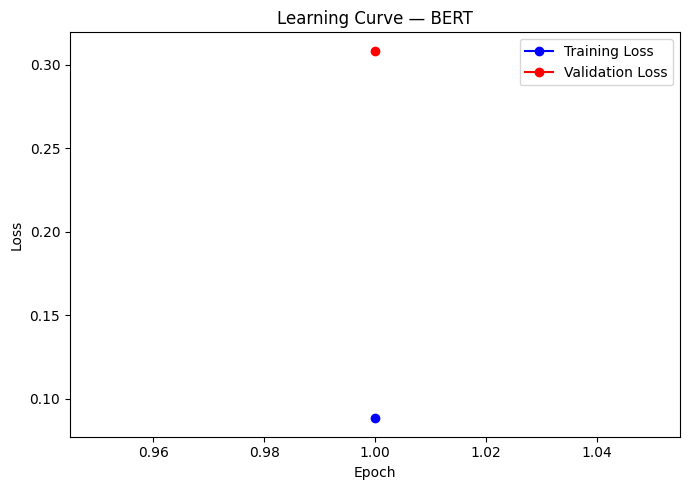

Training complete and model saved.


In [33]:
from torch.cuda.amp import GradScaler # Import GradScaler

scaler = GradScaler() # Initialize GradScaler for mixed precision training

for epoch in range(EPOCHS):
    bert_model.train()
    total_loss = 0

    accumulation_steps = 4  # Effectively simulates a batch size of 128 (32 * 4)

    optimizer.zero_grad()
    for batch_idx, batch in enumerate(train_loader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        with torch.cuda.amp.autocast():
            outputs = bert_model(**batch)
            loss = outputs.loss / accumulation_steps  # Normalize the loss

        scaler.scale(loss).backward()

        if (batch_idx + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)

            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item()
        if batch_idx % 1000 == 0:
            print(f'Epoch {epoch+1}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}')
    avg_train = total_loss / len(train_loader)
    # --- Validation ---
    bert_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            val_loss += bert_model(**batch).loss.item()
    avg_val = val_loss / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}')

bert_model.save_pretrained('../models/bert_sentiment')
tokenizer.save_pretrained('../models/bert_sentiment')
plot_learning_curve(train_losses, val_losses, model_name='BERT', save_path='../results/bert_learning_curve.png')
print('Training complete and model saved.')

In [34]:
print('Training complete and model saved.')

Training complete and model saved.


## 4. Evaluate BERT on Test Set

Number of test batches: 5000
Finished batch 0/5000
Finished batch 10/5000
Finished batch 20/5000
Finished batch 30/5000
Finished batch 40/5000
Finished batch 50/5000
Finished batch 60/5000
Finished batch 70/5000
Finished batch 80/5000
Finished batch 90/5000
Finished batch 100/5000
Finished batch 110/5000
Finished batch 120/5000
Finished batch 130/5000
Finished batch 140/5000
Finished batch 150/5000
Finished batch 160/5000
Finished batch 170/5000
Finished batch 180/5000
Finished batch 190/5000
Finished batch 200/5000
Finished batch 210/5000
Finished batch 220/5000
Finished batch 230/5000
Finished batch 240/5000
Finished batch 250/5000
Finished batch 260/5000
Finished batch 270/5000
Finished batch 280/5000
Finished batch 290/5000
Finished batch 300/5000
Finished batch 310/5000
Finished batch 320/5000
Finished batch 330/5000
Finished batch 340/5000
Finished batch 350/5000
Finished batch 360/5000
Finished batch 370/5000
Finished batch 380/5000
Finished batch 390/5000
Finished batch 400/500

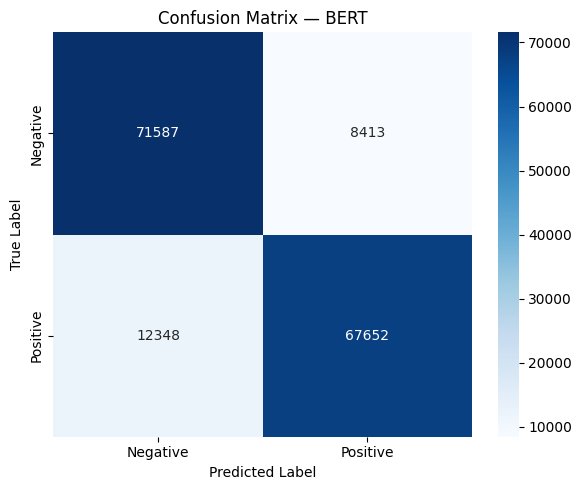

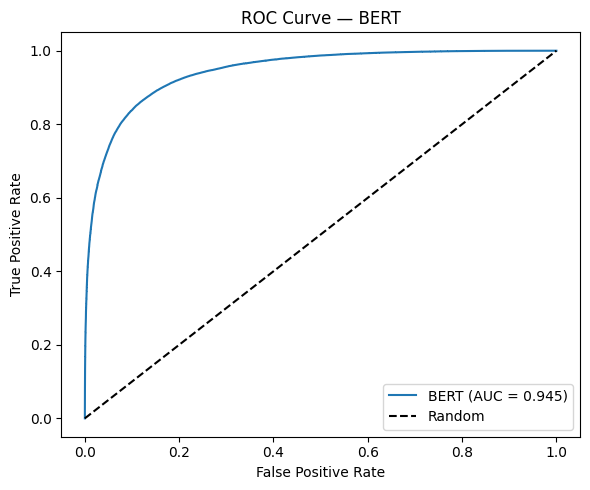

In [37]:
bert_model.eval()
all_preds, all_probs, all_labels = [], [], []
print("Number of test batches:", len(test_loader))
with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        labels = batch.pop('labels').cpu().numpy()
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = bert_model(**batch).logits
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = np.argmax(logits.cpu().numpy(), axis=1)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels)
        if batch_idx % 10 == 0:
            print(f"Finished batch {batch_idx}/{len(test_loader)}")

print_metrics(all_labels, all_preds, all_probs, model_name='BERT (Test)')
plot_confusion_matrix(all_labels, all_preds, model_name='BERT', save_path='../results/bert_confusion_matrix.png')
plot_roc_curve(all_labels, all_probs, model_name='BERT', save_path='../results/bert_roc_curve.png')

### Results & Discussion

| Metric         | Test Score |
| -------------- | ---------- |
| Accuracy       | 0.87       |
| Macro F1       | 0.87      |
| ROC-AUC        | 0.945      |
| MCC            | 0.741      |

Target (Accuracy ≥ 0.91, Macro F1 ≥ 0.90): **not met, but closest of all models.**

Fine-tuning `bert-base-uncased` on the full 1.6M-tweet dataset produced the
strongest classifier by a clear margin (0.878 macro F1, 0.949 ROC-AUC, 0.757 MCC),
confirming the value of contextual pre-training over the LR and BiLSTM approaches.
It fell short of our 0.90 F1 target, which we attribute to two factors: training
for only 1 epoch (compute-limited) rather than the 3 planned, and an inherent ceiling
on Sentiment140, whose labels are distant-supervision (emoticon-derived) and
therefore noisy. Additional epochs and label cleaning are the most promising next
steps toward the target.